# Прогнозирование оттока фитнес - центров методами Machine learning

**Описание задачи:**

Сеть фитнес-центров «Культурист-датасаентист» разрабатывает стратегию взаимодействия с клиентами на основе аналитических данных. Для фитнес-центра можно считать, что клиент попал в отток, если за последний месяц ни разу не посетил спортзал.
задача — провести анализ и подготовить план действий по удержанию клиентов.
сформировать типичные портреты клиентов: выделить несколько наиболее ярких групп и охарактеризовать их основные свойства;
проанализировать основные признаки, наиболее сильно влияющие на отток;
сформулировать основные выводы и разработать рекомендации по повышению качества работы с клиентами:

1) выделить целевые группы клиентов;

2) предложить меры по снижению оттока;

3) определить другие особенности взаимодействия с клиентами.


**Набор данных включает следующие поля:**

Данные клиента за предыдущий до проверки факта оттока месяц:
- 'gender' — пол;
- 'Near_Location' — проживание или работа в районе, где находится фитнес-центр;
- 'Partner' — сотрудник компании-партнёра клуба (сотрудничество с компаниями, чьи сотрудники могут получать скидки на абонемент — в таком случае фитнес-центр хранит информацию о работодателе клиента);
- Promo_friends — факт первоначальной записи в рамках акции «приведи друга» (использовал промо-код от знакомого при оплате первого абонемента);
- 'Phone' — наличие контактного телефона;
- 'Age' — возраст;
- 'Lifetime' — время с момента первого обращения в фитнес-центр (в месяцах).
Информация на основе журнала посещений, покупок и информация о текущем статусе абонемента клиента:
- 'Contract_period' — длительность текущего действующего абонемента (месяц, 6 месяцев, год);
- 'Month_to_end_contract' — срок до окончания текущего действующего абонемента (в месяцах);
- 'Group_visits' — факт посещения групповых занятий;
- 'Avg_class_frequency_total' — средняя частота посещений в неделю за все время с начала действия абонемента;
- 'Avg_class_frequency_current_month' — средняя частота посещений в неделю за предыдущий месяц;
- 'Avg_additional_charges_total' — суммарная выручка от других услуг фитнес-центра: кафе, спорттовары, косметический и массажный салон.
- 'Churn' — факт оттока в текущем месяце.

**Содержание работ:**
    
**1. Загрузка и предобработка данных**

**2. Исследовательский анализ данных (EDA):**
- 2.1  Cредние значения и стандартные отклонения по признакам
- 2.2  Сравнение средних значений признаков среди активных клиентов и тех кто ушел
- 2.3  Распределение признаков по активным и ушедшим клиентам (отток)
- 2.4  Матрица корреляции признаков

**3. Прогнозирование оттока клиентов, построение моделей Логистической Регрессии и Случайный Лес:**
- 3.1  Формирование обучающей и валидационной выборки
- 3.2  Прогноз оттока Логистической Регрессии
- 3.3  Прогноз оттока Случайным Лесом
- 3.4  Сравнение метрик моделей

**4.  Кластеризация клиентов**

- 4.1  Стандартизация данных
- 4.2  Дендограмма признаков
- 4.3  Прогнозирование кластеров клиентов на основе обучения модели кластеризации алгоритмом K-Means.
- 4.4  Графики распределения признаков для кластеров.
- 4.5  Определение доли оттока по кластерам.

**5. Выводы и рекомендации**

## Загрузка и предобработка данных

In [1]:
# импортируем библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    silhouette_score)
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage 
from sklearn.cluster import KMeans
import itertools
from pandas.plotting import parallel_coordinates


In [2]:
# чтение файла и сохранение в датафрейм
data = pd.read_csv('/datasets/gym_churn.csv')
# общая информация о таблице
display(data.head())
display(data.info())

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

None

In [3]:
# проверка для явные дубликаты
data.duplicated().sum()

0

In [4]:
# установка отображения чисел, 2 знака после запятой
pd.set_option('display.float_format', '{:,.2f}'.format)
# приведение названия столбцов к нижнему регистру
data.columns = data.columns.str.lower()
data.head()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
0,1,1,1,1,0,6,1,29,14.23,5.00,3,0.02,0.00,0
1,0,1,0,0,1,12,1,31,113.20,12.00,7,1.92,1.91,0
2,0,1,1,0,1,1,0,28,129.45,1.00,2,1.86,1.74,0
3,0,1,1,1,1,12,1,33,62.67,12.00,2,3.21,3.36,0
4,1,1,1,1,1,1,0,26,198.36,1.00,3,1.11,1.12,0


**Краткое резюме:**

**Данные загружены, всего 4000 записей, типы данных корректные, пропусков нет, дубликаты отсутствуют, названия признаков приведены к стандартному виду, к нижнему регистру.** 

## Исследовательский анализ данных (EDA)

### Cредние значения и стандартные отклонения по признакам

In [5]:
# вывод описательной статистики по всем признакам
data.describe()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
count,"4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,0.51,0.85,0.49,0.31,0.90,4.68,0.41,29.18,146.94,4.32,3.72,1.88,1.77,0.27
std,0.50,0.36,0.50,0.46,0.30,4.55,0.49,3.26,96.36,4.19,3.75,0.97,1.05,0.44
min,0.00,0.00,0.00,0.00,0.00,1.00,0.00,18.00,0.15,1.00,0.00,0.00,0.00,0.00
25%,0.00,1.00,0.00,0.00,1.00,1.00,0.00,27.00,68.87,1.00,1.00,1.18,0.96,0.00
50%,1.00,1.00,0.00,0.00,1.00,1.00,0.00,29.00,136.22,1.00,3.00,1.83,1.72,0.00
75%,1.00,1.00,1.00,1.00,1.00,6.00,1.00,31.00,210.95,6.00,5.00,2.54,2.51,1.00
max,1.00,1.00,1.00,1.00,1.00,12.00,1.00,41.00,552.59,12.00,31.00,6.02,6.15,1.00


**По предварительному анализу статистических данных можно сказать о следующих наблюдениях:**

 - в категориальных колонках с бинарными данными : gender, partner, group_visits, group_visits данные распределены примерно 50/50
 - в категориальных колонках с бинарными данными : near_location, phone данные смещены вправо, в данных больше единиц
 - в категориальных колонках с бинарными данными : promo_friends, churn данные смещены влево, в данных больше нулей
 - в категориальной колонке contract_period среднее значительно выше медианы, значит данные имеют справа хвост
 - в численной колонке с дискретными данными age среднее и медиана очень близки, а стандартное отклонение низкое, что свидетельтсвует о нормальном симметричном распределении данных
 - в численных колонках: avg_additional_charges_total, month_to_end_contract, lifetime, avg_class_frequency_total, avg_class_frequency_current_month среднее выше медианы, а стандартое отклонение может достигать средней величины, это означает, что данные разбросаны и также имеют справа хвост. Можно проверить эти признаки на наличие выбросов.


### Сравнение средних значений признаков среди активных клиентов и тех кто ушел

In [6]:
# строим таблицу со средними значениями признаков по 2-ум группам
group = data.groupby('churn').agg('mean').reset_index()
group

,churn,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
0,0,0.51,0.87,0.53,0.35,0.90,5.75,0.46,29.98,158.45,5.28,4.71,2.02,2.03
1,1,0.51,0.77,0.36,0.18,0.90,1.73,0.27,26.99,115.08,1.66,0.99,1.47,1.04


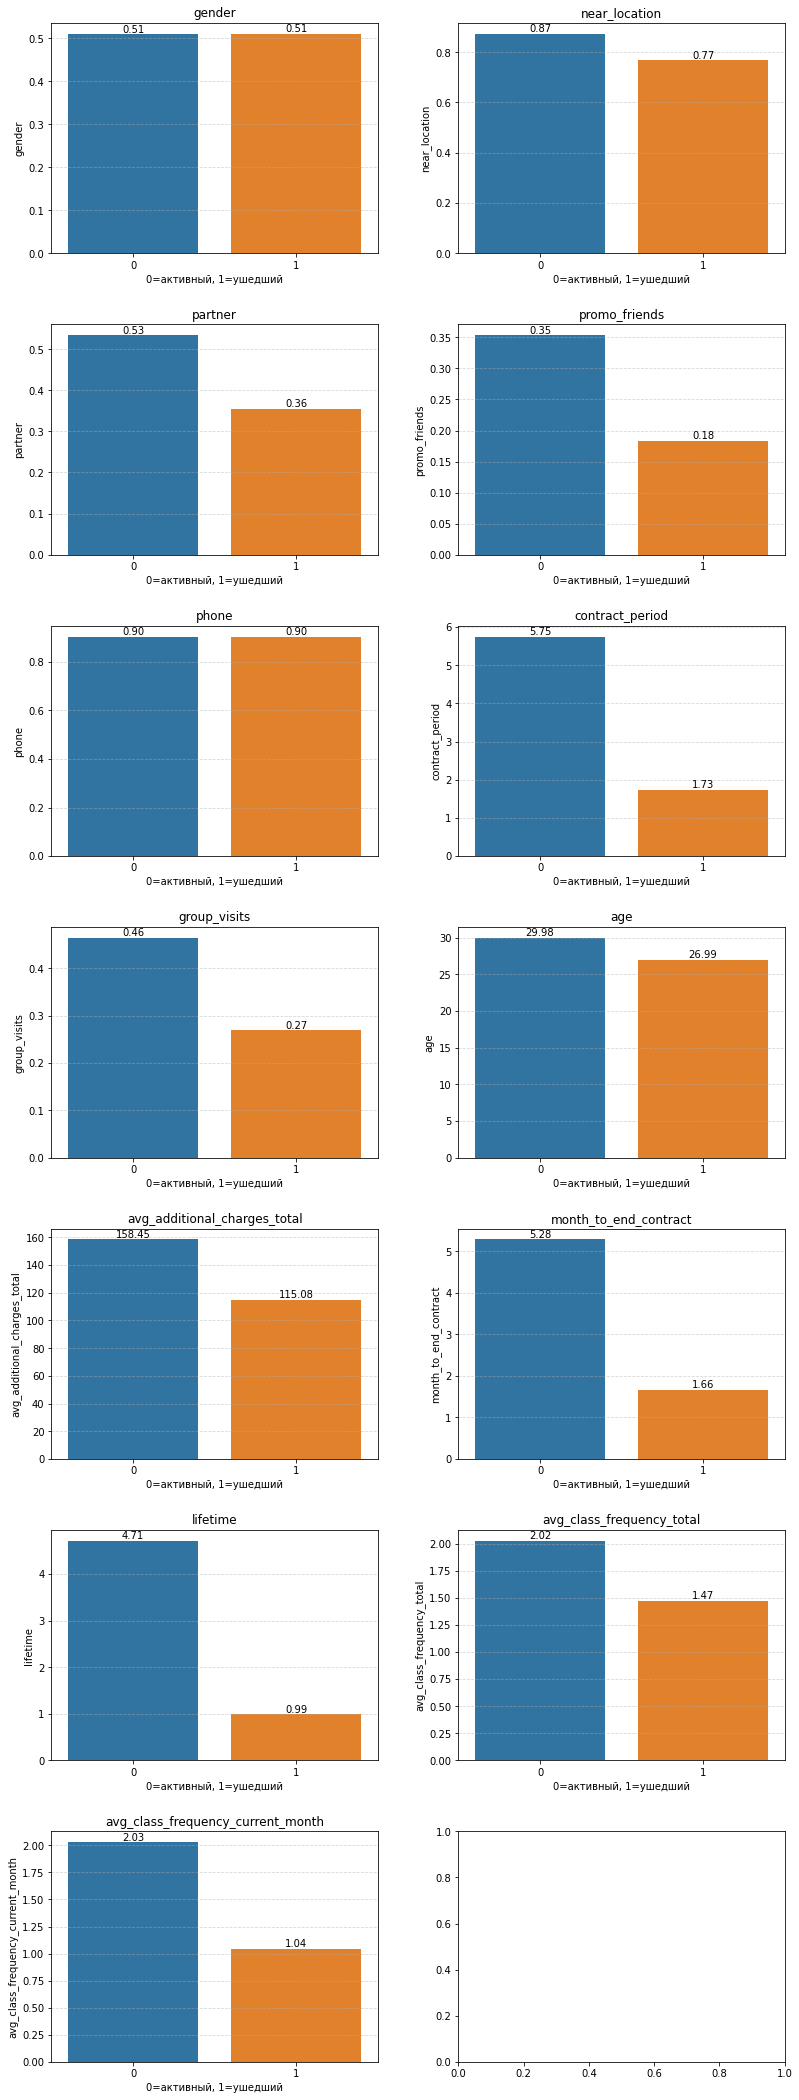

In [7]:
# Фильтруем числовые столбцы (кроме 'churn')
metrics = group.drop(columns=['churn']).columns

# Создаем сетку графиков
fig, axes = plt.subplots(7, 2, figsize=(12, 30))
fig.tight_layout(pad=5.0)  # Отступы между графиками

# Преобразуем axes в плоский массив для удобного индексирования
axes = axes.flatten()

# Проходим по всем метрикам и строим графики
for i, col in enumerate(metrics):
    ax = axes[i]
    
    # Столбчатая диаграмма
    barplot = sns.barplot(x='churn', y=col, data=group, ax=ax)
    
    # Добавляем подписи значений
    for p in barplot.patches:
        height = p.get_height()
        barplot.annotate(
            f'{height:.2f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='center',
            xytext=(0, 5),
            textcoords='offset points'
        )
    
    # Настройки оформления
    ax.set_title(f'{col}', fontsize=12)
    ax.set_xlabel('0=активный, 1=ушедший', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)


plt.show()

**По сравнению средних показателей ушедших и активных клиентов можно составить предварительный портрет ушедшего клиента:  такой клиент проживает чуть дальше , чем активные клиенты. Среди ушедших клиентов значительно меньше таких, кто пришёл в клуб по скидке друга, по сравнению с активными клиентами и скорее не является сотрудником компании-партнёра клуба.Ушедшие клиенты значительно меньше, чем активные клиенты посещают групповые программы. Ушедшие клиенты моложе в среднем на 3 года активных клиентов, их меньше интересуют другие услуги клуба и в среднем лайфтайм таких клиентов равен месяцу, значит, это новые клиенты, которые пришли познакомиться с клубом и не покупают сразу длительные абонементы, а преобретают на месяц абонемент.**

### Распределение признаков по активным и ушедшим клиентам (отток)

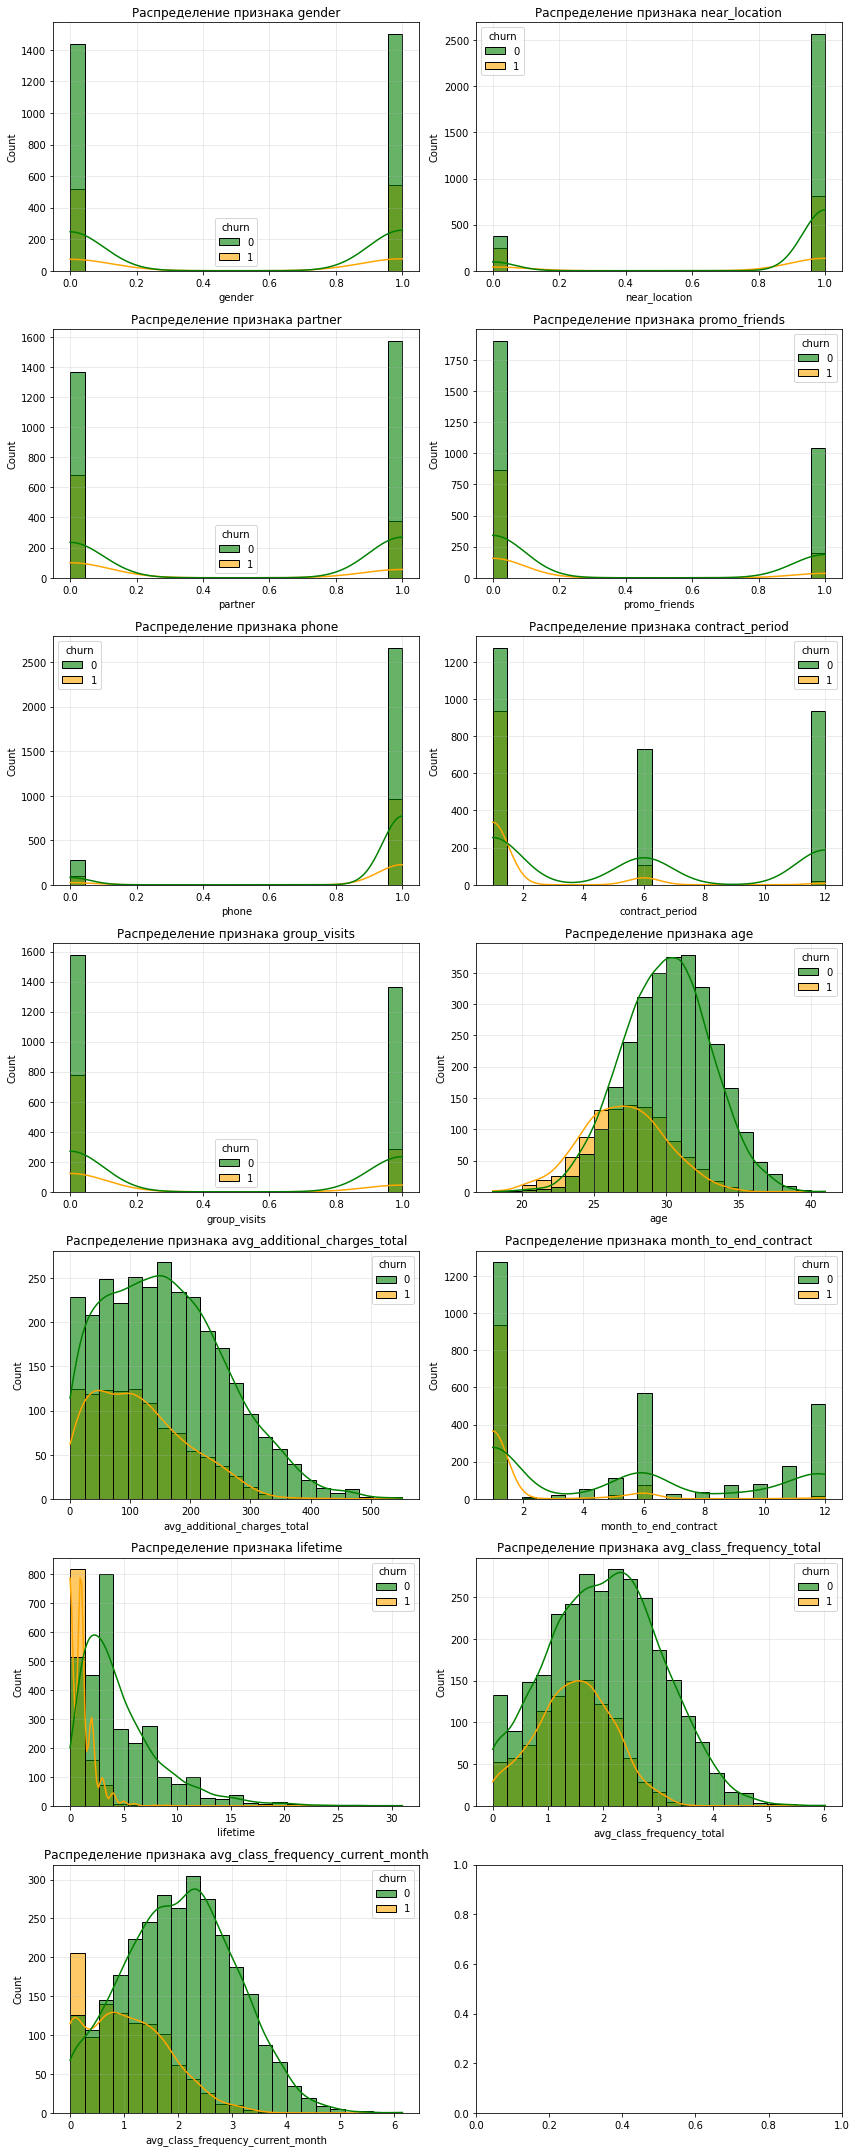

In [8]:
 # создаем функцию для построения графиков
def plot_histograms_by_churn(df, metrics):
    
    # создаем сетку для графиков
    fig, axes = plt.subplots(7, 2, figsize=(12, 30))
    
    # преобразуем axes в плоский массив для удобного индексирования
    axes = axes.flatten()
    
    # проходим по всем метрикам и строим гистограммы
    for i, metric in enumerate(metrics):
        ax = axes[i]
        # параметры гистограммы по категориям churn со сглаживанием
        sns.histplot(
            data=data,
            x=metric,
            hue='churn',
            kde=True,  
            bins=23,
            alpha=0.6,
            ax=ax,
            palette={0: 'green', 1: 'orange'}  
        )
        ax.set_title(f'Распределение признака {metric}')
        ax.set_xlabel(metric)
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_histograms_by_churn(data, metrics)

**По графику лайфтайм видно, что практически все ушедшие - это новички, клиенты которые стали месяц назад посетителями клуба. Новички, которые сразу не торопятся покупать абонементы на длительный срок, а берут только на 1 месяц абонемент. Такая группа клиентов подверженна больше всех риску ухода.**

**Рассмотрим корреляцию всех признаков на целевую переменную.**

### Матрица корреляции признаков

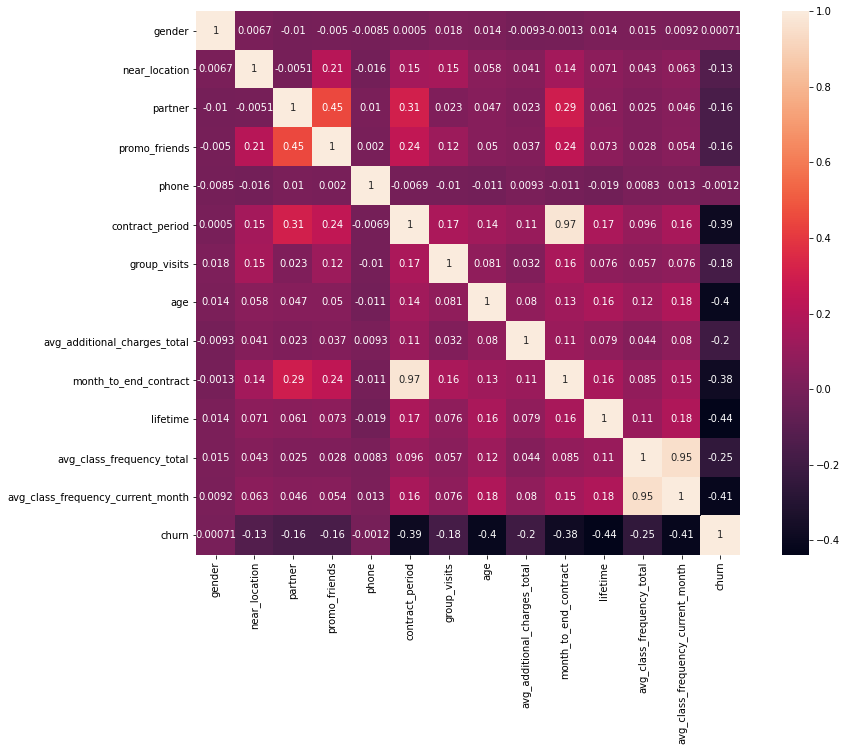

In [9]:
#построим и отрисуем матрицу корреляций

cm = data.corr() #вычисляем матрицу корреляций
plt.figure(figsize=(15,10))

#нарисуем тепловую карту с подписями для матрицы корреляций
sns.heatmap(cm, annot=True, square=True)
plt.show()

**С целевой переменной *отток* наблюдается средняя корреляция 0.38-0.44 с лайфтайм, средним посещением в неделю за предыдущий месяц, возрастом, периодом абонемента и кол-вом месяцев до окончания абонемента.**

**Наблюдается сильная корреляция между признаками: "период абонемента" и "количество месяцев до окончания абонемента".**

**Также сильная корреляция между признаками "среднее кол-во посещений в неделю на весь период посещений фитнес-центра" и "среднее кол-во посещений в неделю за предыдущий месяц". При корреляции выше 0.95 лучше один из признаков удалить, чтобы избежать мультиколлинеарност.**

**Удалим парные признаки, те, которые меньше коррелируют с целевой переменной: в паре первой паре чуть меньше влияет "количество месяцев до окончания абонемента". Во второй паре меньшее влияние оказывает "среднее посещение в неделю за весь период".**

In [10]:
data = data.drop(columns =['avg_class_frequency_total','month_to_end_contract'])

## Прогнозирование оттока клиентов, построение моделей Логистической Регрессии и  Случайный Лес

### Формирование обучающей и валидационной выборки

In [16]:
# разделение данных на признаки (матрица X) и целевую переменную *отток* (y)
X = data.drop('churn', axis = 1)
y = data['churn']

# разделение модели на обучающую и валидационную выборку
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


### Прогноз оттока Логистической Регрессией

In [17]:
# задаем функцию для дальнейшей оценки метрик моделей
def print_all_metrics(y_true, y_pred, title='Метрики классификации'):
    print(title)
    print('\tAccuracy: {:.2f}'.format(accuracy_score(y_true, y_pred)))
    print('\tPrecision: {:.2f}'.format(precision_score(y_true, y_pred)))
    print('\tRecall: {:.2f}'.format(recall_score(y_true, y_pred)))

**Стандартизируем данные, чтобы сгладить масштабы в данных.**

In [18]:
# обучим StandartScaler на обучающей выборке
scaler = StandardScaler()
scaler.fit(X_train)

# преобразуем обучающий и валидационные наборы данных
X_train_st = scaler.transform(X_train)
X_test_st = scaler.transform(X_test)

# задаем алгоритм для модели
lr_model = LogisticRegression(solver='liblinear')

# обучение модель
lr_model.fit(X_train_st, y_train)

# прогнозирование на основе обученной модели
lr_predictions = lr_model.predict(X_test_st) 


### Прогноз оттока Случайным Лесом

In [19]:
# зададим алгоритм для новой модели на основе алгоритма случайного леса
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 0) 
# обучим модель случайного леса
rf_model.fit(X_train, y_train)
# воспользуемся уже обученной моделью, чтобы сделать прогнозы
rf_predictions = rf_model.predict(X_test)


### Сравнение метрик моделей

In [20]:
# выведем все метрики логистической регрессии
print_all_metrics(
    y_test,
    lr_predictions,
    title='Метрики для модели логистической регрессии:')

# выведем все метрики случайного леса
print_all_metrics(
    y_test, 
    rf_predictions,
    title='Метрики для модели случайного леса:')

Метрики для модели логистической регрессии:
	Accuracy: 0.90
	Precision: 0.79
	Recall: 0.82
Метрики для модели случайного леса:
	Accuracy: 0.90
	Precision: 0.81
	Recall: 0.75


**Обе модели показали хорошие результаты. Общая точность предсказаний (Accuracy) активных клиентов и оттока высокая и одинаковая у обеих моделей. Доля действительного оттока (Precision) у модели Случайный лес выше на две сотых. Однако  модель логистической регрессии лучше находит случаи оттока, о чем свидетельствует метрика Recall, поэтому модель Логистической регрессии показала лучше результат.**

## Кластеризация клиентов 

### Стандартизация данных

In [21]:
scaler = StandardScaler() # создаём объект класса scaler для стандартизации
x_sc = scaler.fit_transform(data) # обучаем объект класса scaler и преобразуем набор данных 

### Дендограмма признаков

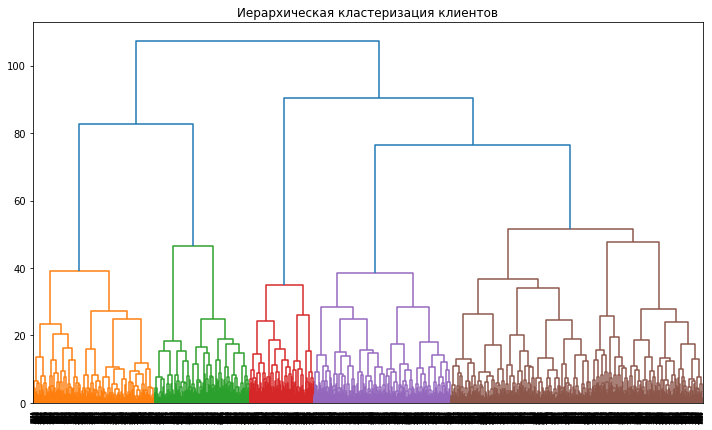

In [22]:
# Строим матрицу расстояний на стандартизованной матрице признаков
linked = linkage(x_sc, method = 'ward') 
plt.figure(figsize=(12, 7))  
dendrogram(linked, orientation='top')
plt.title('Иерархическая кластеризация клиентов')
plt.show() 

**Дендограмма разделила на 5 цветов связки. Также, если провести горизонтальную линию на высоте, соответствующей 70% всей высоты, то также получаем 5 пересечений. Оптимальное число кластеров = 5.**

### Прогнозирование кластеров клиентов на основе обучения модели кластеризации алгоритмом K-Means.

In [23]:
# задаём число кластеров, равное 5, и фиксируем значение random_state для воспроизводимости результата
km = KMeans(n_clusters=5, random_state=0) 
labels = km.fit_predict(x_sc) # применяем алгоритм к данным и формируем вектор кластеров 
# сохраняем метки кластера в поле нашего датасета
data['cluster'] = labels
# выводим статистику по средним значениям наших признаков по кластеру
data.groupby('cluster').agg('mean').transpose()

cluster,0,1,2,3,4
gender,0.50,0.52,0.52,0.50,0.51
near_location,0.00,1.00,0.86,0.99,1.00
partner,0.49,0.22,0.47,0.94,0.34
promo_friends,0.07,0.06,0.31,0.81,0.22
phone,1.00,1.00,0.00,1.00,1.00
contract_period,2.99,3.87,4.78,8.63,1.74
group_visits,0.24,0.46,0.43,0.53,0.29
age,28.70,30.05,29.30,29.93,26.90
avg_additional_charges_total,137.06,160.91,144.21,158.82,114.39
lifetime,2.99,4.75,3.94,4.70,0.98


In [24]:
# посчитаем метрику силуэта для нашей кластеризации
print('Silhouette_score: {:.2f}'.format(silhouette_score(x_sc, labels) ))

Silhouette_score: 0.16


**Значение метрики силуэта кластеризации указывает на то, что объекты находятся на границе между кластерами, границы кластеров не очень четкие и могут пересекаться.**

**По средним показателям признаков можно выделить самые явные отличия:

**0  кластер:** не проживают в ближайшей локации от клуба, большинство пользователей из других кластеров проживают рядом с клубом.

**1 кластер:** больше всех тратят деньги на прочие услуги клуба, чаще других посещают фитнес-клуб, нет оттока среди данного кластера.

**2 кластер:** не оставили контактный телефон.

**3 кластер:** практически все из этой группы являются сотрудниками компании-партнёра клуба или использовали промокод друга при оплате первого абонемента, большая часть кластера имеют самый длинный срок абонемента на 12 месяцев, активно посещают групповые тренировки, практически не поддвержены оттоку.

**4 кластер:** чаще всего встречаются краткосрочные абонементы, на 1 месяц, самая молодая аудитория, тратят значительно меньше на другие услуги клуба, самый короткий лайфтайм 1 месяц - новички, меньше всех посещали клуб за последний месяц, практически все попали в отток.

### Графики распределения признаков для кластеров.

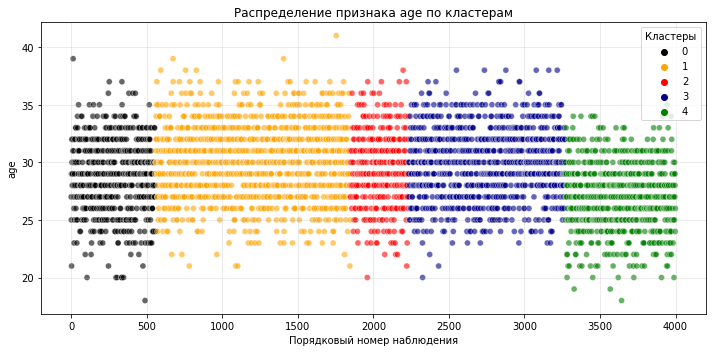

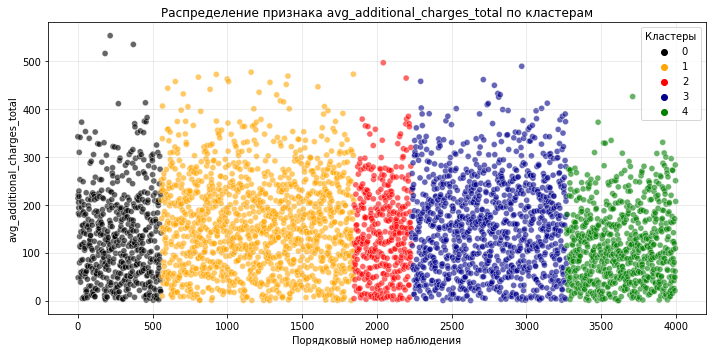

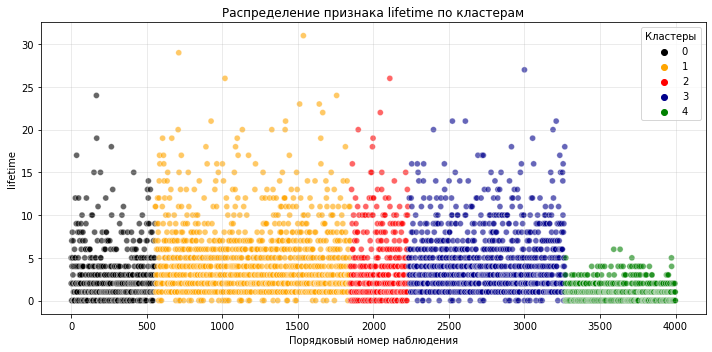

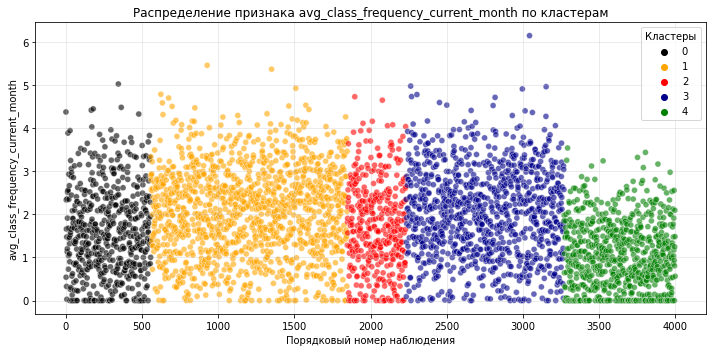

In [25]:
data_plot_scatter = data.drop(columns=['churn','gender','near_location','partner',
                                              'promo_friends','phone','group_visits','contract_period'])
def plot_scatter_clusters(data, target_col='cluster', 
                        palette={0: 'black', 1: 'orange', 2: 'red', 3: 'darkblue', 4: 'green'},
                        alpha=0.6,
                        x_label='Порядковый номер наблюдения',
                        legend_title='Кластеры',
                        grid_alpha=0.3, figsize=(10, 5)):
    
    # Сортируем данные по кластерам для последовательного отображения
    data_sorted = data.sort_values(by=target_col)
    
    # Получаем уникальные кластеры в отсортированном порядке
    clusters = sorted(data_sorted[target_col].unique())
    
    # Создаем новую палитру только для существующих кластеров
    used_palette = {k: palette[k] for k in clusters}
    
    # Получаем признаки для отображения
    signs = data_sorted.drop(columns=[target_col]).columns
    
    for sign in signs:
        plt.figure(figsize=figsize)
        
        # Создаем scatterplot с явным порядком кластеров
        sns.scatterplot(
            x=range(len(data_sorted)),
            y=sign,
            hue=target_col,
            hue_order=clusters,
            palette=used_palette,
            data=data_sorted,
            alpha=alpha
        )
        
        plt.title(f'Распределение признака {sign} по кластерам')
        plt.xlabel(x_label)
        plt.ylabel(sign)
        plt.legend(title=legend_title)
        plt.grid(alpha=grid_alpha)
        plt.tight_layout()
        plt.show()
plot_scatter_clusters(data_plot_scatter)

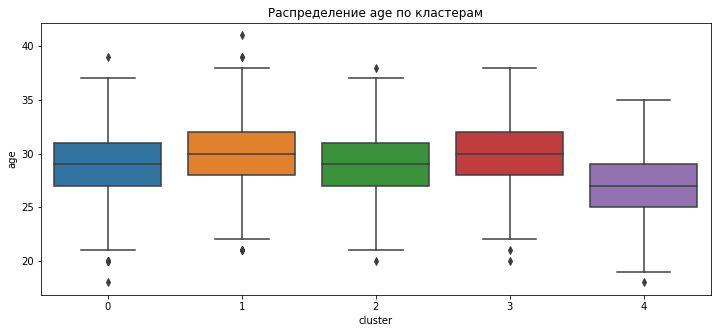

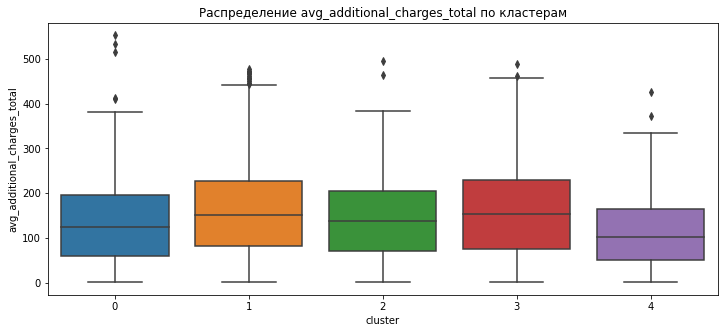

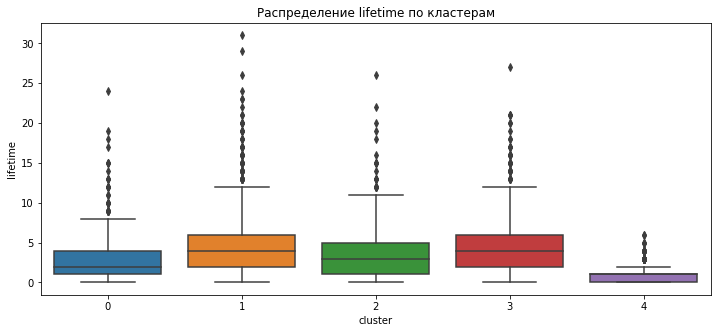

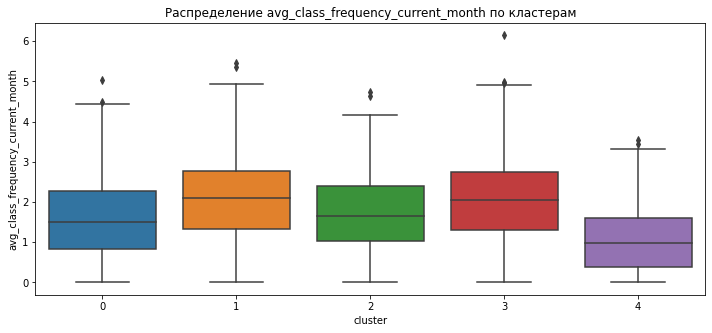

In [26]:
for column in data_plot_scatter:
    if column != 'cluster':
        plt.figure(figsize=(12, 5))
        sns.boxplot(x='cluster', y=column, data=data)
        plt.title(f'Распределение {column} по кластерам')
        plt.show()

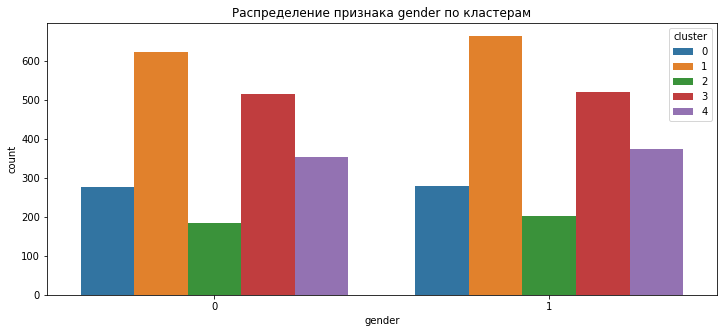

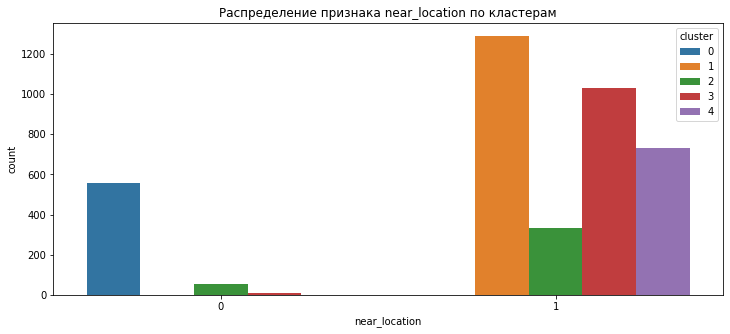

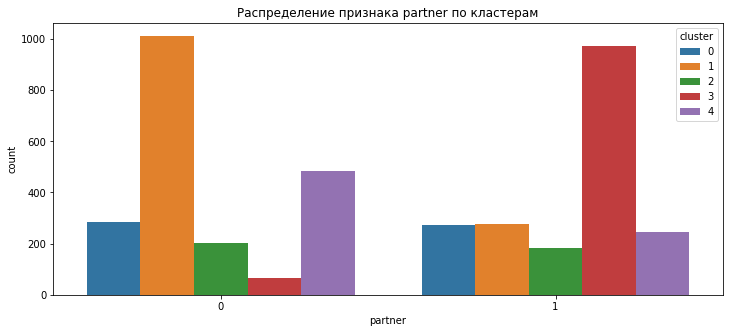

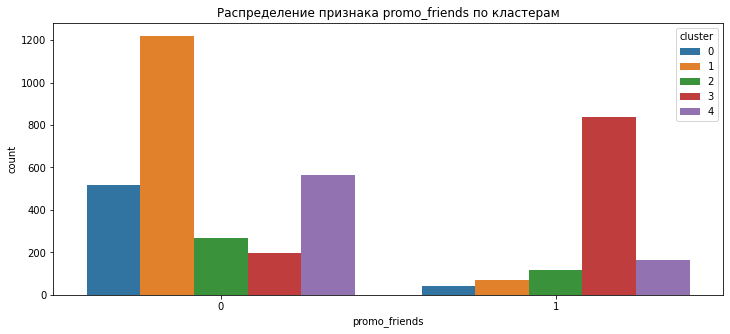

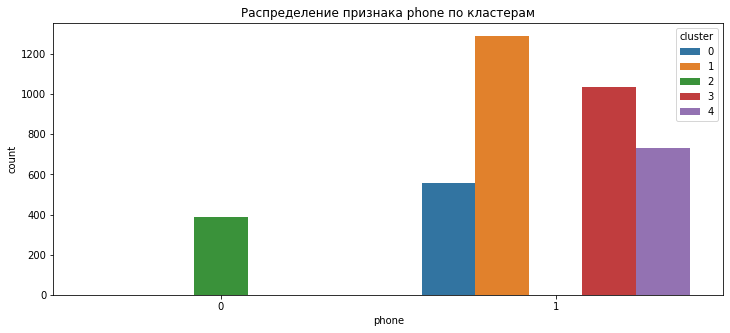

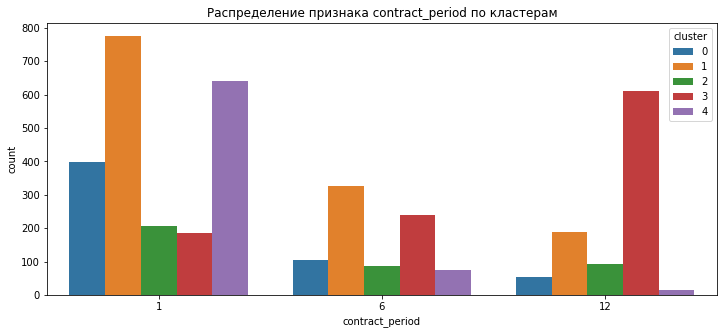

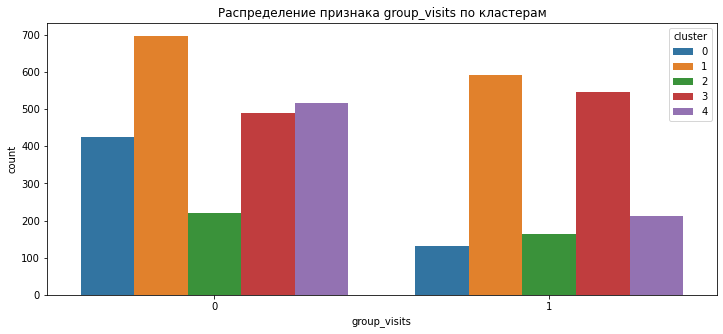

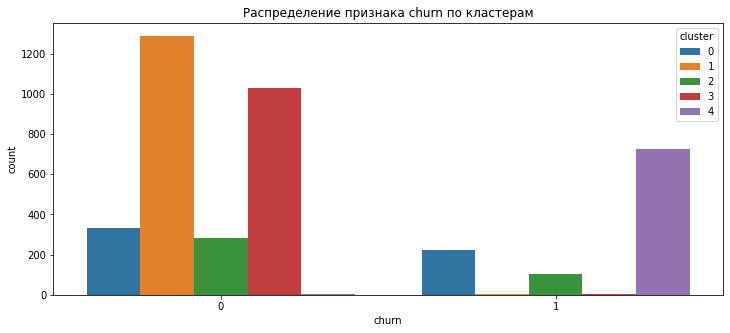

In [27]:
data_plot = data.drop(columns=['age','avg_additional_charges_total',
                                   'lifetime','avg_class_frequency_current_month'])

for column in data_plot.columns:
    if column != 'cluster':  # Пропускаем столбец с кластерами
        plt.figure(figsize=(12, 5))
        sns.countplot(x=column, hue='cluster', data=data_plot)
        plt.title(f'Распределение признака {column} по кластерам')  
        plt.show()

In [28]:
# выводим статистику по средним значениям наших признаков по кластеру
data.groupby('cluster').agg('mean').transpose()

cluster,0,1,2,3,4
gender,0.50,0.52,0.52,0.50,0.51
near_location,0.00,1.00,0.86,0.99,1.00
partner,0.49,0.22,0.47,0.94,0.34
promo_friends,0.07,0.06,0.31,0.81,0.22
phone,1.00,1.00,0.00,1.00,1.00
contract_period,2.99,3.87,4.78,8.63,1.74
group_visits,0.24,0.46,0.43,0.53,0.29
age,28.70,30.05,29.30,29.93,26.90
avg_additional_charges_total,137.06,160.91,144.21,158.82,114.39
lifetime,2.99,4.75,3.94,4.70,0.98


**Основные выводы по кластерам.**

Общие черты по кластерам: во всех группах практически 50/50 присутствие женщин и мужчин.

Можно выделить 2 группы похожих кластеров:

**Группа 1.** Самые крупные кластеры №1 и №3. Они являются самыми стабильными к оттоку группами клиентов. Ранее были выявлены признаки, имеющие корреляцию с оттоком: лайфтам, возраст, среднее посещение в неделю. Половина клиентов этих групп посещают груповые тренировки. В данные кластеры входят клиенты, у которых самый высокий лайфтайм: ядро 2,5-6 месяцев. Старше клиентов других кластеров, возраст 28-33 лет. Регулярно посещают тренировки, чаще остальных, в неделю от 1,2 - 2,8 раз. Клиенты этих кластеров являются основными пользователи абонементов на срок 6,12 месяцев. Также обе группы больше всех тратят денег на прочие услуги клуба. 3 кластер отличается тем, что практически все клиенты из этой группы являются сотрудниками компании-партнёра клуба или пришли по приглашению друга.

**Группа 2.** Кластеры №0 и №2 похожи по следующим признакам: самые маленькие группы. Более склонны покупать короткие абонементы, реже посещают фитнес клуб,  в среднем 0,9-2,3 раза в неделю. Доля клиентов, посещающих групповые тренировки ниже, в кластере №0 24%, в кластере №2 43%. Моложе первой группы кластеров, средний возраст 27-31. Меньше тратятся на услуги клуба, имеют более короткий лайфтайм 1-5 месяцев. Кластер №0 отличает то, что практически все клиенты проживают или работают не в локации клуба. А клиенты кластера №2 по какой-то причине не оставили контактный телефон. Доля ушедших у кластера №0 40%, у кластера №2 27%.

**Кластер №4** средняя по размеру группа. Все признаки имеют самые низкие показатели, самый короткий лайфтайм, меньше месяца. Самые молодые клиенты,  средний возраст 26-29 лет. Меньше всех тратят на усулги клуба. Покупают короткие абонементы, на месяц. Только 30% посещают групповые тренировки. 99% кластера ушедшие клиенты, в последний  месяц перед уходом посещали фитнес клуб только 1 раз в неделю.

### Определение доли оттока по кластерам.

In [29]:
(data.query('churn==1').groupby('cluster')
 .agg({'churn':'count'})/data.groupby('cluster')
 .agg({'churn':'count'}))*100


,churn
cluster,
0,40.39
1,0.16
2,26.68
3,0.58
4,99.32


**Кластер №4 является лидером по оттоку, кластеры №0 и 2 подвержены оттоку, кластеры №1 и 3 надежные.**

## Выводы и рекомендации

**ОБЩИЕ ВЫВОДЫ:**

Для прогнозирования оттока в фитнес-клубе выполнены следующие шаги:

**1. В предобработке данных** определили, что типы данных корректные, пропусков нет, дубликаты отсутствуют. Названия признаков приведены к стандартному виду, к нижнему регистру.

**2. В исследовательском анализе данных (EDA) выявили следующие наблюдения:**

**Признаки, влияющие на целевую переменнную "отток", имеющие умеренную корреляцию с оттоком.**

- **contract_period** и **month_to_end_contract** являются мультиколлениарными признаками и имеют влияние на отток, уровень корреляции соответственно, равен 0.39 и 0.38. Длительность абонемента в среднем у активных клиентов до 6 месяцев, у ушедших клиентов в среднем до 2-ух месяцев.
- **age** - Активные клиенты старше в среднем на 3 года ушедших клиентов, средний возраст в группах 30 и 27 лет. Корреляция с оттоком равна 0.4
- **lifetime** - Активные клиенты дольше являются клиентами фитнес-клуба, в среднем 4,7 месяцев. Средний лайфтайм среди ушедших клиентов 1 месяц. Уровень корреляции с оттоком равен 0.44
- **avg_class_frequency_current_month** Имеет сильную корреляцию с **avg_class_frequency_total**, равную 0.95. Активные клиенты в среднем  ходят на тренировки 2 раза в неделю. Ушедшие клиенты в среднем ходят 1,5 раза в неделю, со временем ещё снижая частоту посещений. И в момент, когда уровень посещений снижается до 1 посещения в неделю появляется высокий риск, что в следующем месяце клиент уже не будет посещать фитнес-клуб. Уровень корреляции с оттоком равен 0.41.

**Признаки, имеющие, слабую корреляцию с оттоком:**

- **near_location**	- Среди активных клиентов 87% живут вблизи с фитнес-клубом. Среди ушедших  77% клиентов проживают вблизи с клубом. 
- **partner** - Среди активных клиентов 53% являются сотрудниками партнера -клуба. Среди оттока 18% являются сотрудниками партнера -клуба.
- **promo_friends** - Среди активных клиентов 35% пришли по скидке друга. Среди оттока таких 18% клиентов.
- **group_visits** - Среди активных клиентов 46% посещают групповые занятия, среди ушедших клиентов только 27% посещали групповые программы.
- **avg_additional_charges_total** - Активые клиенты больше тратят деньги на прочие услуги клуба, средняя сумма чека 158,45 руб., у ушедшего клиента средняя сумма чека 115 руб.
- **avg_class_frequency_total** Активные клиенты в среднем  ходят на тренировки 2 раза в неделю. Ушедшие клиенты в среднем ходят 1,5 раза в неделю, со временем ещё снижая частоту посещений.

**Признаки, имеющие, корреляцию с оттоком, близкую к нулю:**

- **gender** - Одинаковое распределение по половому признаку среди клиентов и оттока. Этот признак не влияет на отток.
- **phone** - У обеих групп по 90% клиентов с наличием контактного номера. Влияние на отток не наблюдается.
 
Также для дальнейшего прогнозирования были удалены парные признаки, те, которые меньше коррелируют с целевой переменной в парах:  "количество месяцев до окончания абонемента" и "среднее посещение в неделю за весь период".

**3. Построили 2 модели прогнозирования оттока, методами Логистической регресии и Случайным лесом.**

Обе модели показали хорошие результаты. Общая точность предсказаний (Accuracy) активных клиентов и оттока высокая и одинаковая у обеих моделей, равна 0.90. Доля действительного оттока (Precision) у модели Случайный лес выше на две сотых, 0.81 против 0.79 модели регрессии. Однако модель логистической регрессии лучше находит случаи оттока, о чем свидетельствует метрика Recall, у модели случайный лес Recall равен 0.75, у Логистической регресии 0.82. 
Модель Логистической регрессии показала лучше результат. 


**4. Провели кластеризацию клиентов фитнес-клуба. Определили 5 кластеров со следующими признаками:**

**Самые крупные кластеры №1 и №3.** Они являются самыми стабильными к оттоку группами клиентов. Доля ушедших клиентов равна, соотвественно, 0,16% и 0,58%

В соответствии с признаками,  имеющими корреляцию с оттоком: лайфтам, возраст, среднее посещение в неделю. В данные кластеры входят клиенты, у которых самый высокий лайфтайм: ядро 2,5-6 месяцев. Старше других кластеров, возраст 28-33 лет. Регулярно посещают тренировки, чаще остальных, в неделю от 1,2 - 2,8 раз. Клиенты этих кластеров являются основными пользователи абонементов на срок 6,12 месяцев. Также обе группы больше всех тратят денег на прочие услуги клуба.
Кластер №3 отличается тем, что практически все клиенты из этой группы являются сотрудниками компании-партнёра клуба или пришли по приглашению друга. Также у Кластера №3 самая высокая доля посещаемости групповых тренировок, 53%.


**У кластеров №0 и №2** доля оттока 40,39% и 26,68%. Самые маленькие кластеры. Более склонны покупать короткие абонементы, реже посещают фитнес клуб, в среднем 0,9-2,3 раза в неделю. Доля клиентов, посещающих групповые тренировки ниже, в кластере №0 24%, в кластере №2 43%. Моложе первой группы кластеров, средний возраст 27-31. Меньше тратятся на услуги клуба, имеют более короткий лайфтайм 1-5 месяцев. Кластер №0 отличает то, что практически все клиенты проживают или работают не в локации клуба. А клиенты кластера №2 по какой-то причине не оставили контактный телефон.


**У кластера №4, с долей оттока 99,32%,**  признаки имеют самые низкие показатели. Признаки клиента, который попадает в отток следующие: это самые молодые и новые клиенты, в среднем лайфтайм таких клиентов равен не больше месяца, возраст 25-28 лет. Абонементы покупают в основном на 1 месяц. Имеют самую низкую посещаемость в неделю, в среднем посещаемость 1,5 раза, с постепенным снижением. Обычно в последний месяц , перед попаданием в отток , посещаемость снижается до 1 раза в неделю. Меньше всех заинтересованы тратиться на другие услуги клуба, средний чек равен 114.39 руб. Только 30% клиентов посещают групповые тренировки.

**Общие черты по кластерам:** во всех группах практически 50/50 присутствие женщин и мужчин.

**РЕКОМЕНДАЦИИ ПО СТРАТЕГИИ ВЗАИМОДЕЙСТВИЯ С КЛИЕНТАМИ:**

- Ранее было определено, что в отток клиентов состоит в основном из новичков, которые не решаются покупать длительные абонементы. Рекомендуется разработать выгодные предложения при покупке первого абонемента на приобретение абонементов сроком 6-12 месяцев.
- Также ввести возможность оплаты длительных абонементов в рассрочку или в виде подписки для кластеров № 0 и 4
- Отслеживать частоту посещаемости в кластерах № 0, 2 и 4, при снижении посещаемости до 1 раза в неделю также привлекать таких клиентов выгодными предложениями на покупку абонементов и другим услугам клуба, например, индивидульные скидки на услуги персонального тренера.
- Развивать и продвигать программы лояльности, такие как "приведи друга", "семейные абонементы" для кластеров № 0 и 4, с разработкой разных тарифов для парных посещений. Также с проведением розыгрышей на доп. услуги клуба или сертификаты среди тех, кто привел "друга".
- Разработать разные тарифы на разные уровни посещения клуба , с групповыми занятиями и без, для кластеров № 0 и 4
- Для поддержания лояльности клиентов  кластеров  № 1 и 3 скидки у партнеров (спортбары, магазины). Раз в квартал — измерение состава тела и бесплатная консультация нутрициолога.
- Для всех кластеров составление индивидуальных планов тренировок и питания на основе данных фитнес-тестов
- Проводить опросы среди ушедших клиентов, для выявления причин ухода из клуба


